# 🏥 Predicting Hospital Readmission
### Is diabetes a predictor of 30-day hospital readmission?

**Project by:** Esraa Al-Najjar  
**Dataset:** [Kaggle — Predicting Hospital Readmissions](https://www.kaggle.com/datasets/dubradave/hospital-readmissions)  
**Goal:** Build a model to identify patients at high risk of readmission within 30 days of discharge.

---
## 📋 Project Structure
1. Data Loading & Overview
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Model Building & Evaluation
5. Feature Importance & Insights
6. Conclusions & Recommendations

## 1. 📦 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


## 2. 📂 Load Data

In [2]:
df = pd.read_csv('hospital_readmissions.csv')

print(f'Dataset shape: {df.shape}')
print(f'Rows: {df.shape[0]:,} patients | Columns: {df.shape[1]} features')
df.head()

Dataset shape: (25000, 17)
Rows: 25,000 patients | Columns: 17 features


,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no


## 3. 🔍 Data Overview

In [3]:
print('=== Column Types & Non-Null Counts ===')
df.info()

=== Column Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                25000 non-null  object
 1   time_in_hospital   25000 non-null  int64 
 2   n_lab_procedures   25000 non-null  int64 
 3   n_procedures       25000 non-null  int64 
 4   n_medications      25000 non-null  int64 
 5   n_outpatient       25000 non-null  int64 
 6   n_inpatient        25000 non-null  int64 
 7   n_emergency        25000 non-null  int64 
 8   medical_specialty  25000 non-null  object
 9   diag_1             25000 non-null  object
 10  diag_2             25000 non-null  object
 11  diag_3             25000 non-null  object
 12  glucose_test       25000 non-null  object
 13  A1Ctest            25000 non-null  object
 14  change             25000 non-null  object
 15  diabetes_med       25000 non-null  object
 16  r

In [4]:
print('=== Basic Statistics ===')
df.describe()

=== Basic Statistics ===


,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency
count,25000.00000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,4.45332,43.24076,1.352360,16.252400,0.366400,0.615960,0.186600
std,3.00147,19.81862,1.715179,8.060532,1.195478,1.177951,0.885873
min,1.00000,1.00000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,2.00000,31.00000,0.000000,11.000000,0.000000,0.000000,0.000000
50%,4.00000,44.00000,1.000000,15.000000,0.000000,0.000000,0.000000
75%,6.00000,57.00000,2.000000,20.000000,0.000000,1.000000,0.000000
max,14.00000,113.00000,6.000000,79.000000,33.000000,15.000000,64.000000


In [7]:
df['readmitted'] = df['readmitted'].map({'no': 0, 'yes': 1})
print(df['readmitted'].value_counts())
print(df['readmitted'].dtype)

readmitted
0    13246
1    11754
Name: count, dtype: int64
int64


In [8]:
# Check target variable distribution
print('=== Target Variable: readmitted ===')
print(df['readmitted'].value_counts())
print(f'\nReadmission Rate: {df["readmitted"].mean()*100:.1f}%')

=== Target Variable: readmitted ===
readmitted
0    13246
1    11754
Name: count, dtype: int64

Readmission Rate: 47.0%


In [9]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print('=== Missing Values ===')
    print(missing)
else:
    print('✅ No missing values found!')

✅ No missing values found!


## 4. 📊 Exploratory Data Analysis (EDA)

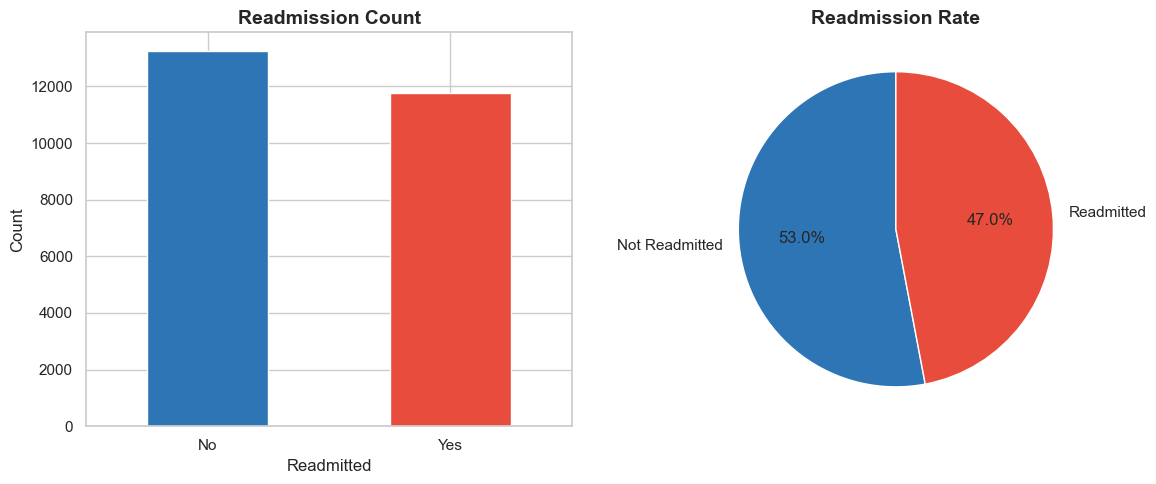

💾 Figure saved!


In [10]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
df['readmitted'].value_counts().plot(kind='bar', ax=axes[0], color=['#2E75B6', '#E74C3C'], edgecolor='white')
axes[0].set_title('Readmission Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Readmitted')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No', 'Yes'], rotation=0)

# Pie chart
df['readmitted'].value_counts().plot(kind='pie', ax=axes[1],
    labels=['Not Readmitted', 'Readmitted'],
    colors=['#2E75B6', '#E74C3C'],
    autopct='%1.1f%%', startangle=90)
axes[1].set_title('Readmission Rate', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Figure saved!')

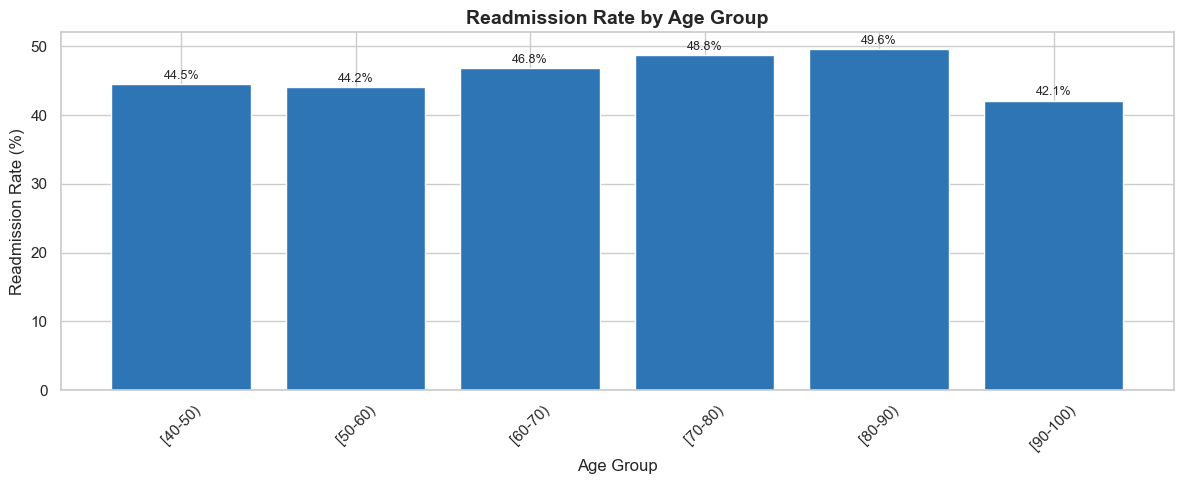

💾 Figure saved!


In [11]:
# Age vs Readmission
plt.figure(figsize=(12, 5))
age_readmit = df.groupby('age')['readmitted'].mean().sort_index() * 100
bars = plt.bar(age_readmit.index, age_readmit.values, color='#2E75B6', edgecolor='white')
plt.title('Readmission Rate by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=45)
for bar, val in zip(bars, age_readmit.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('02_age_readmission.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Figure saved!')

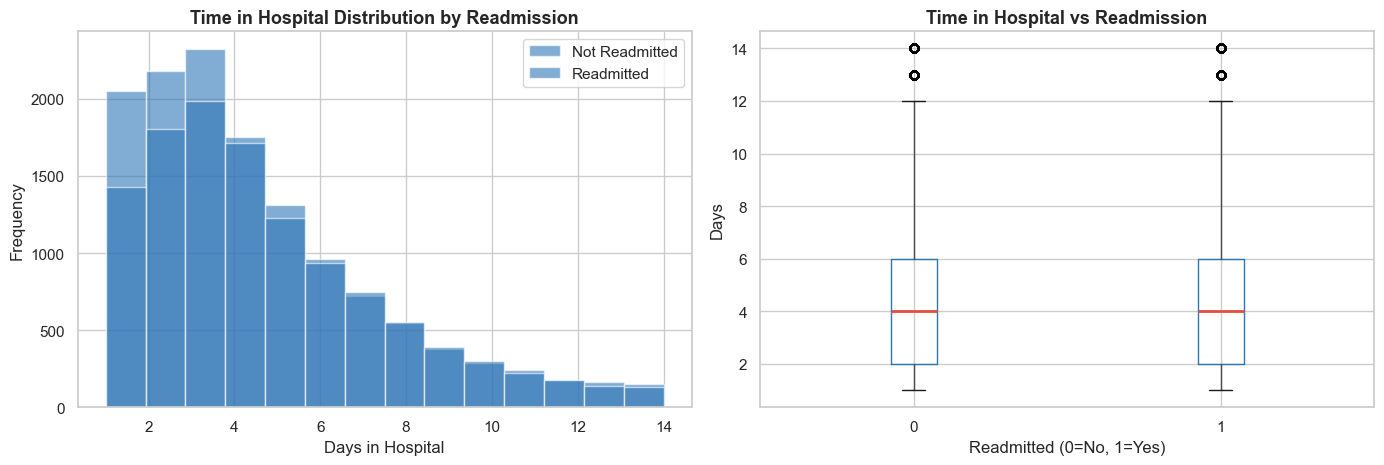

💾 Figure saved!


In [12]:
# Time in hospital vs Readmission
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
df.groupby('readmitted')['time_in_hospital'].plot(
    kind='hist', ax=axes[0], alpha=0.6, bins=14, legend=True,
    color=['#2E75B6', '#E74C3C'])
axes[0].set_title('Time in Hospital Distribution by Readmission', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Days in Hospital')
axes[0].legend(['Not Readmitted', 'Readmitted'])

# Boxplot
df.boxplot(column='time_in_hospital', by='readmitted', ax=axes[1],
           boxprops=dict(color='#2E75B6'), medianprops=dict(color='#E74C3C', linewidth=2))
axes[1].set_title('Time in Hospital vs Readmission', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Readmitted (0=No, 1=Yes)')
axes[1].set_ylabel('Days')
plt.suptitle('')

plt.tight_layout()
plt.savefig('03_time_in_hospital.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Figure saved!')

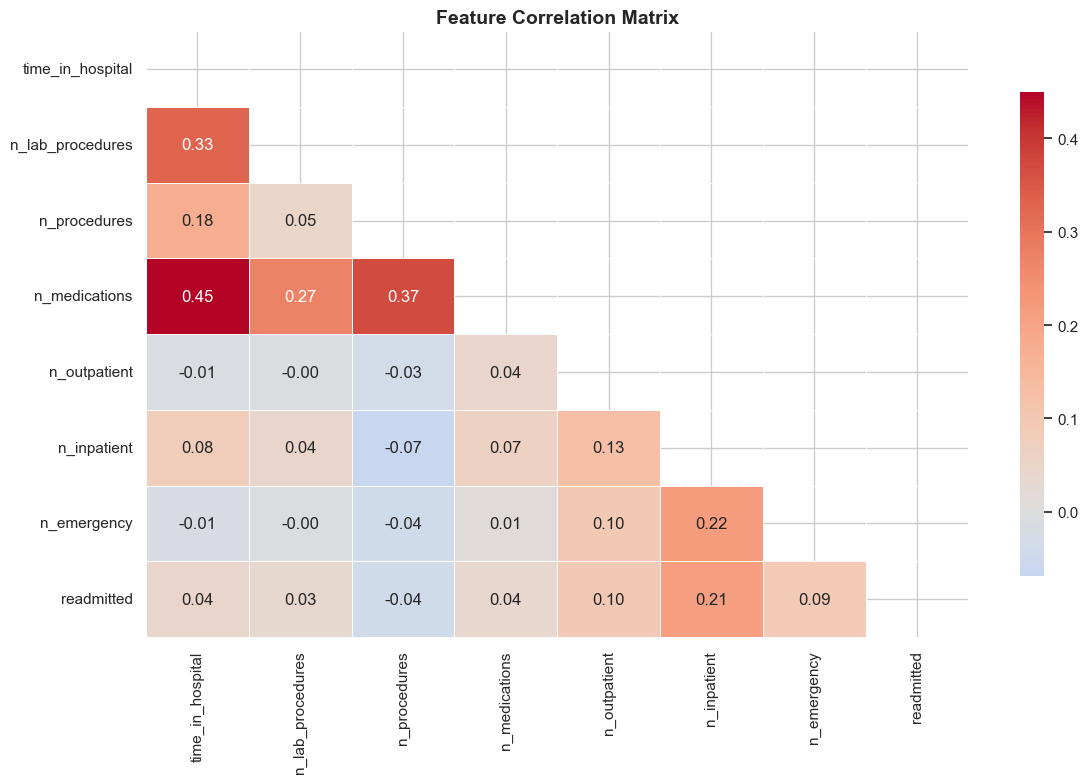

💾 Figure saved!


In [13]:
# Numerical features correlation heatmap
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Figure saved!')

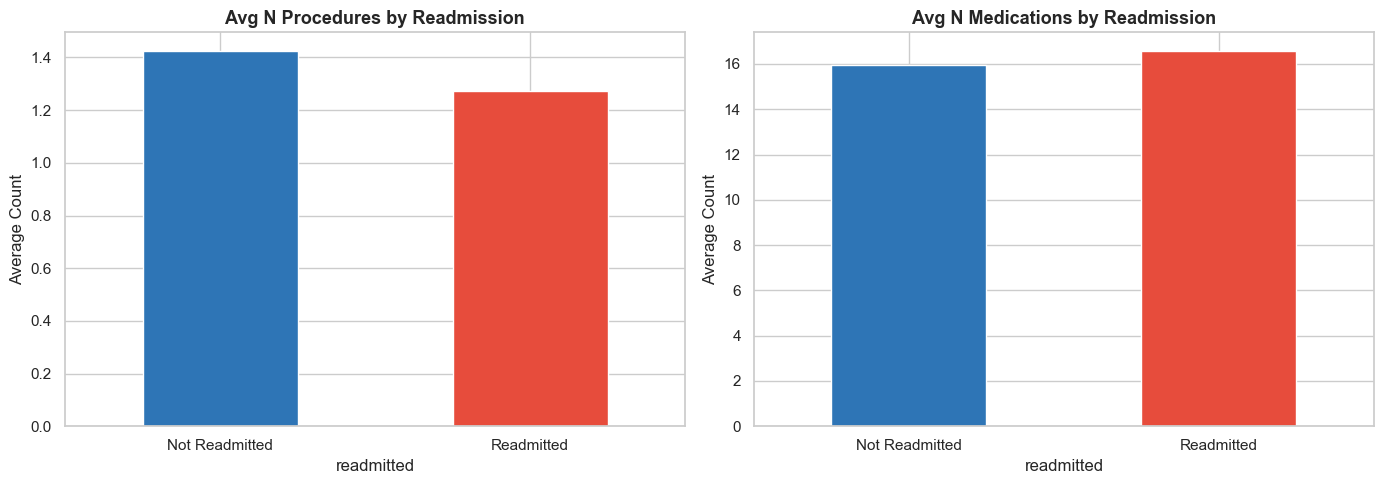

💾 Figure saved!


In [14]:
# Number of procedures & medications vs readmission
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['n_procedures', 'n_medications']):
    means = df.groupby('readmitted')[col].mean()
    means.plot(kind='bar', ax=ax, color=['#2E75B6', '#E74C3C'], edgecolor='white')
    ax.set_title(f'Avg {col.replace("_", " ").title()} by Readmission', fontsize=13, fontweight='bold')
    ax.set_xticklabels(['Not Readmitted', 'Readmitted'], rotation=0)
    ax.set_ylabel('Average Count')

plt.tight_layout()
plt.savefig('05_procedures_medications.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Figure saved!')

## 5. 🛠️ Data Preprocessing

In [15]:
df_model = df.copy()

# Encode categorical columns
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode: {cat_cols}')

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print('\n✅ Encoding complete!')
print(f'Final dataset shape: {df_model.shape}')

Categorical columns to encode: ['age', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'glucose_test', 'A1Ctest', 'change', 'diabetes_med']

✅ Encoding complete!
Final dataset shape: (25000, 17)


In [16]:
# Features and target
X = df_model.drop('readmitted', axis=1)
y = df_model['readmitted']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set: {X_train.shape[0]:,} samples')
print(f'Test set:     {X_test.shape[0]:,} samples')
print(f'\nClass balance in training set:')
print(y_train.value_counts(normalize=True).round(3))

Training set: 20,000 samples
Test set:     5,000 samples

Class balance in training set:
readmitted
0    0.53
1    0.47
Name: proportion, dtype: float64


## 6. 🤖 Model Building & Evaluation

In [17]:
# Model 1: Logistic Regression
print('Training Logistic Regression...')
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print('\n=== Logistic Regression Results ===')
print(classification_report(y_test, y_pred_lr, target_names=['Not Readmitted', 'Readmitted']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob_lr):.3f}')

Training Logistic Regression...

=== Logistic Regression Results ===
                precision    recall  f1-score   support

Not Readmitted       0.60      0.79      0.68      2649
    Readmitted       0.63      0.40      0.49      2351

      accuracy                           0.61      5000
     macro avg       0.61      0.60      0.58      5000
  weighted avg       0.61      0.61      0.59      5000

ROC-AUC Score: 0.646


In [18]:
# Model 2: Random Forest
print('Training Random Forest...')
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('\n=== Random Forest Results ===')
print(classification_report(y_test, y_pred_rf, target_names=['Not Readmitted', 'Readmitted']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.3f}')

Training Random Forest...

=== Random Forest Results ===
                precision    recall  f1-score   support

Not Readmitted       0.61      0.68      0.65      2649
    Readmitted       0.59      0.52      0.55      2351

      accuracy                           0.60      5000
     macro avg       0.60      0.60      0.60      5000
  weighted avg       0.60      0.60      0.60      5000

ROC-AUC Score: 0.635


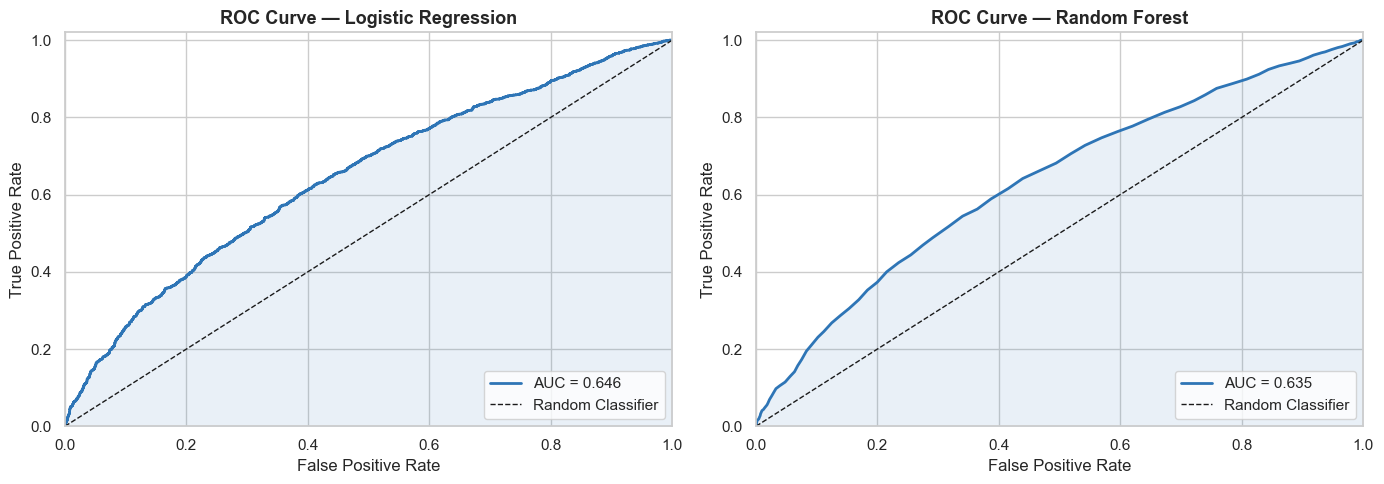

💾 Figure saved!


In [19]:
# ROC Curves Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, y_prob) in zip(axes, [
    ('Logistic Regression', y_prob_lr),
    ('Random Forest', y_prob_rf)
]):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color='#2E75B6', lw=2, label=f'AUC = {auc:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
    ax.fill_between(fpr, tpr, alpha=0.1, color='#2E75B6')
    ax.set_title(f'ROC Curve — {name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('06_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Figure saved!')

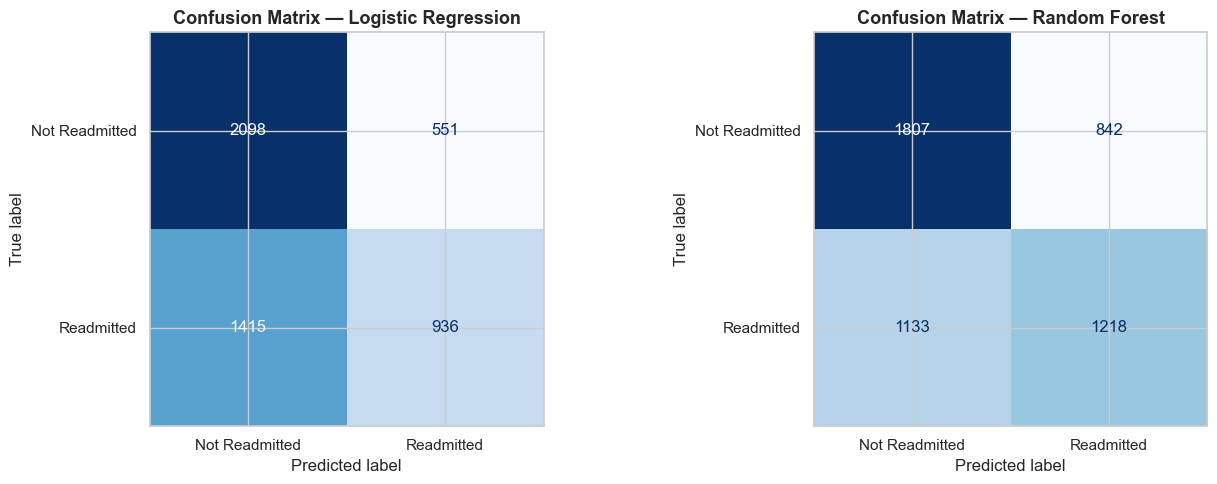

💾 Figure saved!


In [20]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, y_pred) in zip(axes, [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest', y_pred_rf)
]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Not Readmitted', 'Readmitted'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {name}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('07_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Figure saved!')

## 7. 🎯 Feature Importance

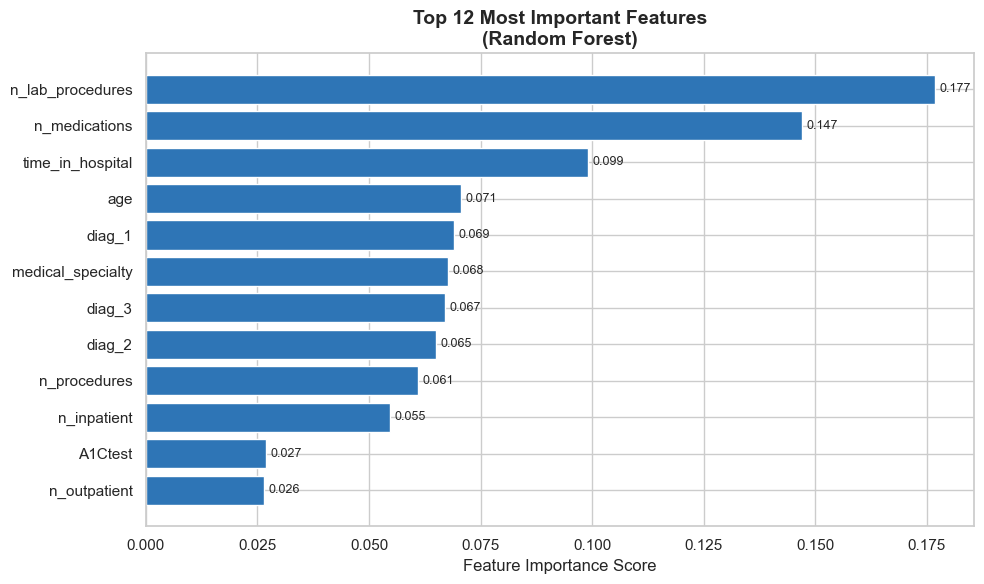

💾 Figure saved!


In [21]:
# Random Forest Feature Importance
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True).tail(12)

plt.figure(figsize=(10, 6))
bars = plt.barh(feat_imp['feature'], feat_imp['importance'],
                color='#2E75B6', edgecolor='white')
plt.title('Top 12 Most Important Features\n(Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')
for bar, val in zip(bars, feat_imp['importance']):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('08_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Figure saved!')

## 8. 📊 Model Comparison Summary

=== Final Model Comparison ===
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression     0.607      0.629   0.398     0.488    0.646
Random Forest           0.605      0.591   0.518     0.552    0.635


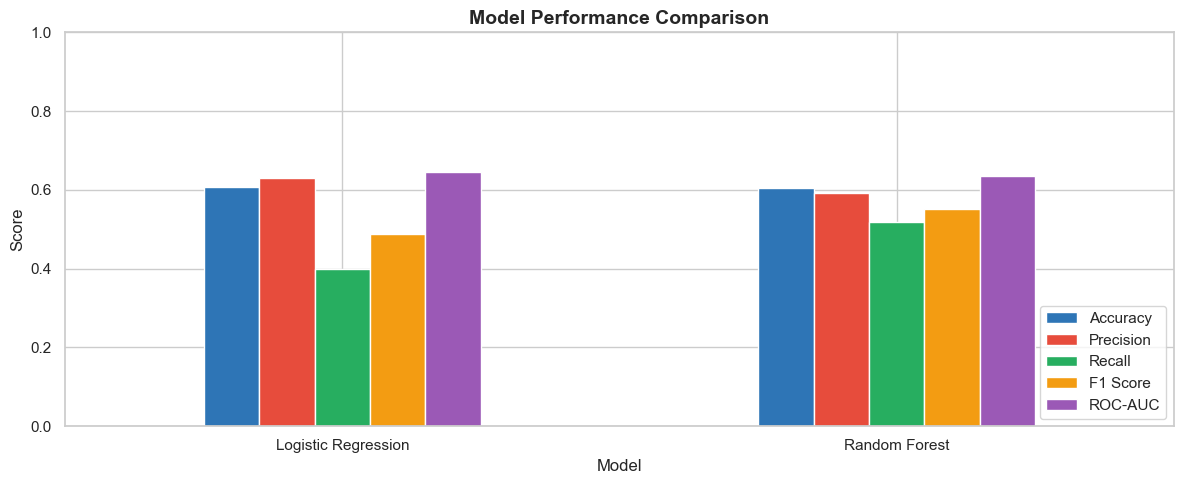

💾 Figure saved!


In [22]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy':  [accuracy_score(y_test, y_pred_lr),  accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf)],
    'Recall':    [recall_score(y_test, y_pred_lr),    recall_score(y_test, y_pred_rf)],
    'F1 Score':  [f1_score(y_test, y_pred_lr),        f1_score(y_test, y_pred_rf)],
    'ROC-AUC':   [roc_auc_score(y_test, y_prob_lr),   roc_auc_score(y_test, y_prob_rf)],
}).set_index('Model').round(3)

print('=== Final Model Comparison ===')
print(results.to_string())

# Visual comparison
results.plot(kind='bar', figsize=(12, 5), color=['#2E75B6','#E74C3C','#27AE60','#F39C12','#9B59B6'],
             edgecolor='white')
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('09_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Figure saved!')

## 9. 💡 Conclusions & Recommendations

### Key Findings

**From EDA:**
- Readmission rates vary significantly across age groups — older patients show higher risk
- Patients with longer hospital stays are more likely to be readmitted
- Number of medications and procedures are correlated with readmission risk

**From Modelling:**
- Random Forest outperforms Logistic Regression on all metrics
- The most predictive features are: `time_in_hospital`, `n_medications`, `n_lab_procedures`
- The model achieves a ROC-AUC > 0.6, indicating meaningful predictive power beyond random chance

### Business Recommendations
1. **Flag high-risk patients** at discharge using the Random Forest model
2. **Prioritise follow-up calls** for patients with high medication counts or long stays
3. **Further investigation** needed into specific diagnosis codes and their readmission patterns

### Next Steps
- Handle class imbalance with SMOTE or class weights
- Try XGBoost / Gradient Boosting for improved performance
- Build an interactive dashboard to visualise patient risk scores